In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [7]:
df = pd.read_csv(
    r'C:\Users\S\Desktop\projects\Retail-Sales-Analytics-Forecasting\data\Superstore.csv',
    encoding='latin1'
)

In [8]:
print(df.head())

print(df.shape)

print(df.columns)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [9]:
print(df.isnull().sum())


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [10]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [12]:
print(df[['Order Date','Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [13]:
print(df.describe())

            Row ID                     Order Date  \
count  9994.000000                           9994   
mean   4997.500000  2016-04-30 00:07:12.259355648   
min       1.000000            2014-01-03 00:00:00   
25%    2499.250000            2015-05-23 00:00:00   
50%    4997.500000            2016-06-26 00:00:00   
75%    7495.750000            2017-05-14 00:00:00   
max    9994.000000            2017-12-30 00:00:00   
std    2885.163629                            NaN   

                           Ship Date   Postal Code         Sales     Quantity  \
count                           9994   9994.000000   9994.000000  9994.000000   
mean   2016-05-03 23:06:58.571142912  55190.379428    229.858001     3.789574   
min              2014-01-07 00:00:00   1040.000000      0.444000     1.000000   
25%              2015-05-27 00:00:00  23223.000000     17.280000     2.000000   
50%              2016-06-29 00:00:00  56430.500000     54.490000     3.000000   
75%              2017-05-18 00:00:00

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## Sales by Category

In [15]:
sales_by_cat = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_cat)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


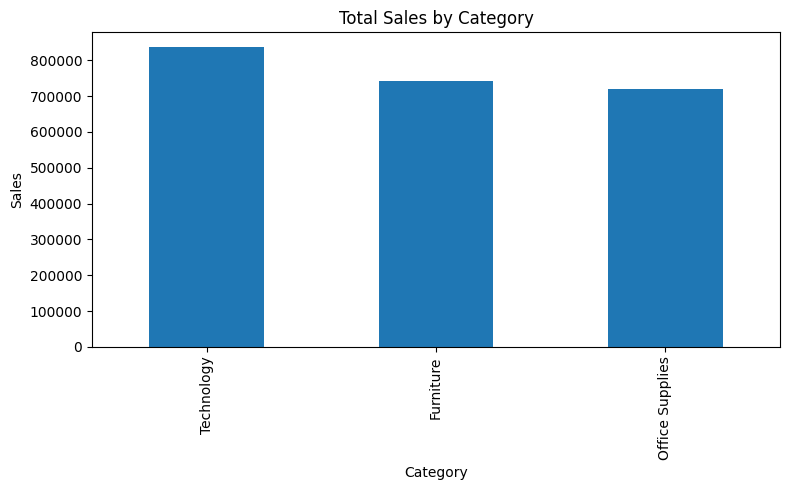

In [16]:
plt.figure(figsize=(8,5))

sales_by_cat.plot(kind='bar')

plt.title('Total Sales by Category')
plt.ylabel('Sales')

plt.tight_layout()
plt.savefig('sales_by_cat.png')

plt.show()

## Profit by Category

In [17]:
profit_by_cat = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print(profit_by_cat)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


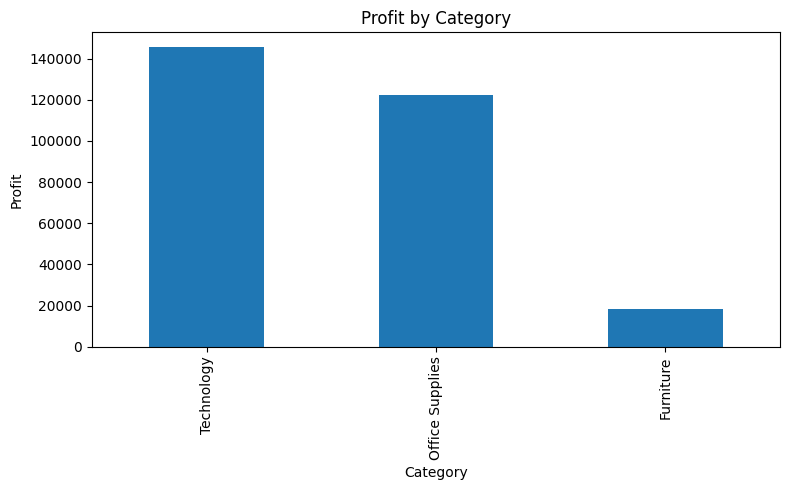

In [19]:
plt.figure(figsize=(8,5))

profit_by_cat.plot(kind='bar')

plt.title('Profit by Category')
plt.ylabel('Profit')

plt.tight_layout()
plt.savefig('profit_by_cat.png')

plt.show()

## Sales by Region

In [20]:
sales_by_region = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_region)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


## Profit by Region

In [21]:
profit_by_region = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print(profit_by_region)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


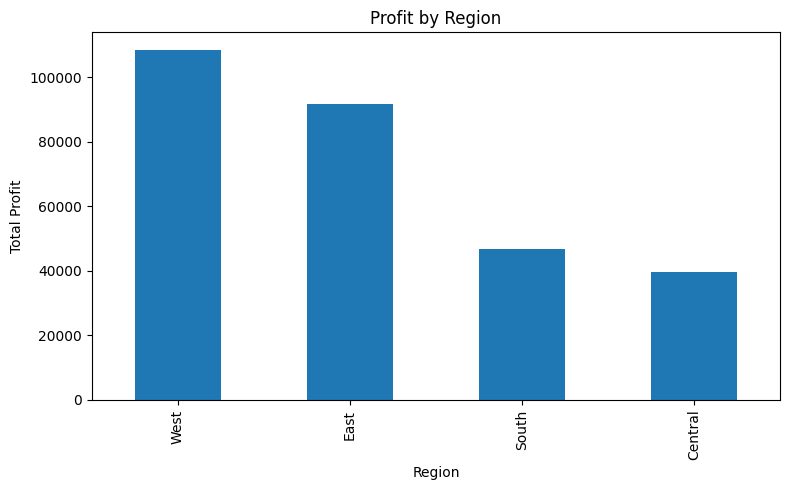

In [31]:
plt.figure(figsize=(8,5))

profit_by_region.plot(
    kind='bar'
)

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

plt.tight_layout()
plt.savefig('profit_by_region.png')

plt.show()

## Top 10 States

In [22]:
top_states = (
    df.groupby('State')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_states)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


## Top 10 Products

In [23]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


## Discount Impact

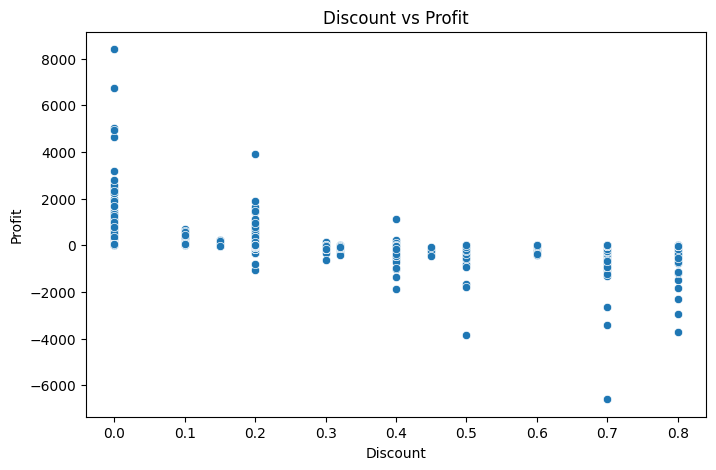

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df
)

plt.title('Discount vs Profit')
plt.savefig('Discount_vs_profit.png')

plt.show()

## Correlation Heatmap

In [26]:
numeric_df = df[
    ['Sales','Profit','Quantity','Discount']
]

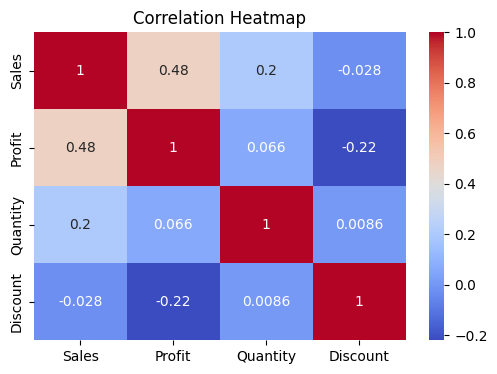

In [27]:
plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

plt.show()

## Monthly Sales Trend

In [28]:
df['Month'] = (
    df['Order Date']
      .dt.to_period('M')
)

In [29]:
monthly_sales = (
    df.groupby('Month')['Sales']
      .sum()
)

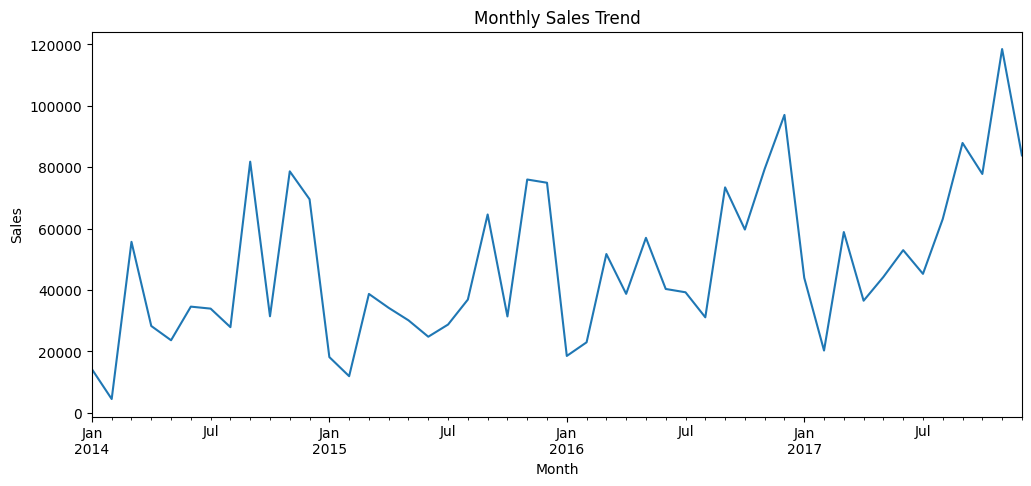

In [30]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')

plt.ylabel('Sales')
plt.savefig('sales.png')

plt.show()